In [1]:
# ==========================================================
# Loan Approval Prediction
# Notebook 06 - Hyperparameter Tuning
# ==========================================================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

from sklearn.model_selection import (
    GridSearchCV,
    RandomizedSearchCV,
    StratifiedKFold
)

from sklearn.metrics import (
    accuracy_score,
    classification_report
)

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from xgboost import XGBClassifier

In [3]:
loan_df = pd.read_csv(
"/Users/lingareddydhanushkumar/Desktop/Codex/ML/01_Loan_Approval_Prediction/data/processed/loan_feature_engineered.csv"
)

loan_df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome,Income_Loan_Ratio,EMI,LoanIncomeRatio,ApplicantIncome_Log,TotalIncome_Log,LoanAmount_Log
0,1,0,0.0,0,0,0.095951,-0.552892,-0.213425,0.274031,1.0,2,1,-0.172910,-0.135268,-0.229622,-0.249273,0.539391,0.022901,-0.013951
1,1,1,1.0,0,0,-0.122234,-0.041852,-0.201115,0.274031,1.0,0,0,-0.133976,-0.094839,-0.224180,-0.329632,0.152174,0.098340,0.001994
2,1,1,0.0,0,1,-0.395052,-0.552892,-0.964324,0.274031,1.0,2,1,-0.631266,-0.151129,-0.561597,-0.216268,-0.520462,-1.219365,-1.340341
3,1,1,0.0,1,0,-0.466919,0.246201,-0.299594,0.274031,1.0,2,1,-0.318992,-0.264151,-0.267718,0.046793,-0.758008,-0.291011,-0.129186
4,1,0,0.0,0,0,0.121975,-0.552892,-0.041088,0.274031,1.0,2,1,-0.148616,-0.227753,-0.153431,-0.043700,0.579856,0.070330,0.198728


In [5]:
X = loan_df.drop("Loan_Status", axis=1)

y = loan_df["Loan_Status"]

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42,

    stratify=y
)

In [9]:
from sklearn.preprocessing import StandardScaler

num_cols = [

"ApplicantIncome",

"CoapplicantIncome",

"LoanAmount",

"Loan_Amount_Term",

"TotalIncome",

"Income_Loan_Ratio",

"EMI",

"LoanIncomeRatio",

"ApplicantIncome_Log",

"LoanAmount_Log",

"TotalIncome_Log"

]

scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(
    X_train[num_cols]
)

X_test[num_cols] = scaler.transform(
    X_test[num_cols]
)

In [11]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [13]:
rf = RandomForestClassifier(
    random_state=42
)

rf_params = {

    "n_estimators":[100,200,300],

    "max_depth":[5,10,15,None],

    "min_samples_split":[2,5,10],

    "min_samples_leaf":[1,2,4]

}

rf_grid = GridSearchCV(

    estimator=rf,

    param_grid=rf_params,

    cv=cv,

    scoring="accuracy",

    n_jobs=-1

)

rf_grid.fit(X_train,Y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [5, 10, 15, None],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300]},
             scoring='accuracy')

In [14]:
print("Best Parameters")

print(rf_grid.best_params_)

print()

print("Best Accuracy")

print(rf_grid.best_score_)

Best Parameters
{'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}

Best Accuracy
0.8179605263157894


In [15]:
best_rf = rf_grid.best_estimator_

pred = best_rf.predict(X_test)

print(classification_report(
    Y_test,
    pred
))

print("Accuracy :",
      accuracy_score(Y_test,pred))

              precision    recall  f1-score   support

           0       0.86      0.47      0.61        38
           1       0.80      0.96      0.87        82

    accuracy                           0.81       120
   macro avg       0.83      0.72      0.74       120
weighted avg       0.82      0.81      0.79       120

Accuracy : 0.8083333333333333


In [19]:
svc = SVC(
    probability=True
)

svc_params = {

"C":[0.1,1,10,100],

"gamma":[1,0.1,0.01,0.001],

"kernel":["linear","rbf"]

}

svc_grid = GridSearchCV(

svc,

svc_params,

cv=cv,

scoring="accuracy",

n_jobs=-1

)

svc_grid.fit(X_train,Y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=SVC(probability=True), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10, 100], 'gamma': [1, 0.1, 0.01, 0.001],
                         'kernel': ['linear', 'rbf']},
             scoring='accuracy')

In [20]:
print(svc_grid.best_params_)

print()

print(svc_grid.best_score_)

{'C': 0.1, 'gamma': 1, 'kernel': 'linear'}

0.8075219298245615


In [21]:
best_svm = svc_grid.best_estimator_

pred = best_svm.predict(X_test)

print(classification_report(
    Y_test,
    pred
))

print(
    accuracy_score(
        Y_test,
        pred
    )
)

              precision    recall  f1-score   support

           0       0.89      0.45      0.60        38
           1       0.79      0.98      0.87        82

    accuracy                           0.81       120
   macro avg       0.84      0.71      0.74       120
weighted avg       0.82      0.81      0.79       120

0.8083333333333333


In [25]:
xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

xgb_params = {

    "learning_rate":[0.01,0.05,0.1,0.2],

    "max_depth":[3,5,7,9],

    "subsample":[0.7,0.8,0.9,1.0],

    "n_estimators":[100,200,300]

}

In [27]:
xgb_random = RandomizedSearchCV(

    estimator=xgb,

    param_distributions=xgb_params,

    n_iter=20,

    cv=cv,

    random_state=42,

    scoring="accuracy",

    n_jobs=-1

)

xgb_random.fit(X_train,Y_train)

RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=True,
                                           eval_metric='logloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,...
                                           max_delta_step=None, max_depth=None,
                                           max_leaves=None,
                                           min_child_weight=None, missing=nan,
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'learning_rate': [0.01, 0.05, 0.1, 0.2],
                                        'max_depth': [3, 5, 7, 9],
                                        'n_estimators': [100, 200, 300],
                                        'subsample': [0.7, 0.8, 0.9, 1.0]},
                   random_state=42, scoring='accuracy')

In [29]:
print(xgb_random.best_params_)

print()

print(xgb_random.best_score_)

{'subsample': 0.9, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.01}

0.8179824561403508


In [31]:
best_xgb = xgb_random.best_estimator_

pred = best_xgb.predict(X_test)

print(classification_report(
    Y_test,
    pred
))

print(
    accuracy_score(
        Y_test,
        pred
    )
)

              precision    recall  f1-score   support

           0       0.82      0.47      0.60        38
           1       0.80      0.95      0.87        82

    accuracy                           0.80       120
   macro avg       0.81      0.71      0.73       120
weighted avg       0.80      0.80      0.78       120

0.8


In [33]:
comparison = pd.DataFrame({

"Model":[

"Random Forest",

"SVM",

"XGBoost"

],

"Best CV Score":[

rf_grid.best_score_,

svc_grid.best_score_,

xgb_random.best_score_

]

})

comparison

,Model,Best CV Score
0,Random Forest,0.817961
1,SVM,0.807522
2,XGBoost,0.817982


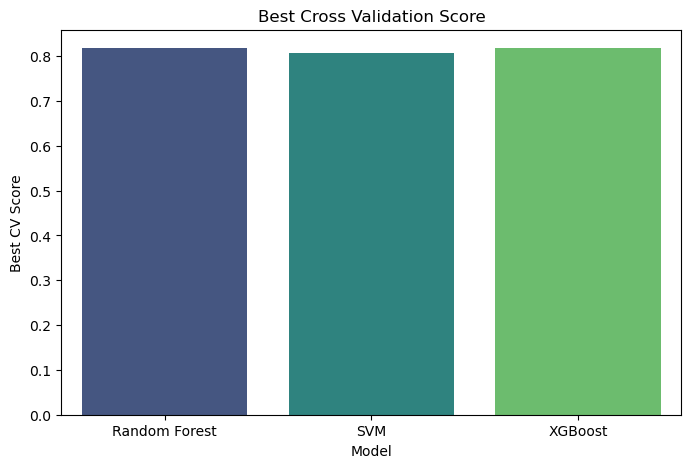

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.barplot(

x="Model",

y="Best CV Score",

data=comparison,

palette="viridis"

)

plt.title("Best Cross Validation Score")

plt.show()

In [37]:
best_model = max(
    [
        ("Random Forest", rf_grid.best_estimator_, rf_grid.best_score_),
        ("SVM", svc_grid.best_estimator_, svc_grid.best_score_),
        ("XGBoost", xgb_random.best_estimator_, xgb_random.best_score_)
    ],
    key=lambda x: x[2]
)

print("Best Model:", best_model[0])
print("CV Score:", best_model[2])

Best Model: XGBoost
CV Score: 0.8179824561403508


In [39]:
import joblib

joblib.dump(
    best_model[1],
    "/Users/lingareddydhanushkumar/Desktop/Codex/ML/01_Loan_Approval_Prediction/models/final_model.pkl"
)

joblib.dump(
    scaler,
    "/Users/lingareddydhanushkumar/Desktop/Codex/ML/01_Loan_Approval_Prediction/models/scaler.pkl"
)

print("Final model and scaler saved successfully!")

Final model and scaler saved successfully!
